# Final Results: Narratives

> **Inputs used here are pre-computed.** Where a cell loads a CSV/NIfTI file, a comment states
> which upstream script produced it. A few inputs this notebook depends on
> (`compiled/info/combined_participant_info.csv`, `compiled/results/*_compiled_results.csv`,
> `compiled/results/combined_corrs.csv`, `compiled/results/combined_corr_analyses.csv`) currently
> have **no generating script in this repo** — see `REPRODUCIBILITY.md` at the repo root.

In [1]:
import numpy as np
import pandas as pd
import os, sys, glob
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
import scipy
import scipy.stats as stats
from scipy.spatial.distance import cdist, pdist, squareform
from scipy.stats import ttest_rel, ttest_ind, wilcoxon, spearmanr
import nilearn
from nilearn import plotting, image, datasets
from nilearn.maskers import NiftiMasker
from nilearn.mass_univariate import permuted_ols
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.anova import anova_lm
import matplotlib.gridspec as gridspec
from patsy import dmatrix
from sklearn.utils import resample
import pingouin as pg
from matplotlib.patches import Patch
from matplotlib import rcParams
import matplotlib.ticker as mticker
from scipy.stats import gaussian_kde

import plotting_helpers as helper          # surface plots, colormaps, dataset colors
import stats_helpers as stats_helpers      # permutation tests, (parcelwise/LME) regression, FDR correction
import parcelwise_regressions as pwr       # run_regression_analyses, join_results_participant_info, clean_difference_dataframe
import hbn_config as hc                    # hc.AGE_BINS / hc.HBN_AGE_GROUPS used for HBN age binning

rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42

PLOT_DIR = 'compiled/plots'
os.makedirs(PLOT_DIR, exist_ok=True)
ISC_CMAP = 'OrRd'
ID_CMAP = helper.custom_blues_cmap()
dataset_colors = helper.dataset_colors('all')

# Global seed: makes every unseeded resample/permutation call below reproducible.
SEED = 4
np.random.seed(SEED)

In [2]:
# Common helper functions -- now defined once in plotting_helpers.py / stats_helpers.py
from plotting_helpers import (
    expand_parcellation_to_volume,  # parcel-array -> 3D volume
    load_atlas, get_region_order,   # Schaefer-400 atlas + region label order
    get_average_results, reorder_region_names,  # average/reindex per-region scores
)
from stats_helpers import lme_fit_summary  # MixedLM fit diagnostics (R^2, ICC, AIC/BIC)

## 1.1 Surface grid: ISC and IDE by task

In [3]:
# INPUT: compiled/results/narratives_compiled_results.csv
#   Per-region (Schaefer-400) ISC and IDE ("TPHATE_DiffOp_IDE") scores per subject x task.
#   Built from aggregate_results_dfs.py's per-dataset parcelwise_results_ISC_IDE.csv
#   (searchlight_IDE_methods.py / atlas_IDE_methods.py for IDE, searchlight_isc.py / atlas_isc.py
#   for ISC); the final compiled_results.csv reshape/rename step has no script currently in this
#   repo -- see REPRODUCIBILITY.md.
narrative_tasks = ['black', 'bronx', 'forgot', 'piemanpni']
measures = {'ISC': 'ISC', 'TPHATE_DiffOp_IDE': 'IDE'}
atlas_img, atlas_labels = load_atlas()

results_df_nar = pd.read_csv('compiled/results/narratives_compiled_results.csv')
avg_results = {}
for task in narrative_tasks:
    avg_results[task] = {}
    for measure in measures.keys():
        avg_results[task][measure] = get_average_results(
            results_df_nar, col_names=['task', 'measure'], target_names=[task, measure],
            value_name='score', region_name_order=atlas_labels)
        print(f"Loaded {task} {measure}: shape {avg_results[task][measure].shape}, "
              f"mean={np.nanmean(avg_results[task][measure]):.3f}")

[get_dataset_dir] Dataset found in /Users/elb/nilearn_data/schaefer_2018
Loaded black ISC: shape (400,), mean=0.074
Loaded black TPHATE_DiffOp_IDE: shape (400,), mean=12.021
Loaded bronx ISC: shape (400,), mean=0.066
Loaded bronx TPHATE_DiffOp_IDE: shape (400,), mean=8.965
Loaded forgot ISC: shape (400,), mean=0.056
Loaded forgot TPHATE_DiffOp_IDE: shape (400,), mean=11.866
Loaded piemanpni ISC: shape (400,), mean=0.069
Loaded piemanpni TPHATE_DiffOp_IDE: shape (400,), mean=7.545


In [4]:
# Narratives: surface grid (4 tasks x 2 measures)
# Uses plotting_helpers.generate_surface_plot + compile_surface_plots_to_grid_by_rows
nifti_images, titles, cbar_ranges, cmaps = [], [], [], []

for measure, label in measures.items():
    for task in narrative_tasks:
        if measure in avg_results[task]:
            vol_img = expand_parcellation_to_volume(avg_results[task][measure], atlas_img)
            nifti_images.append(vol_img)
            titles.append(f'{task.capitalize()}')
            if measure == 'ISC':
                cbar_ranges.append((0, 0.4)); cmaps.append(ISC_CMAP)
            else:
                cbar_ranges.append((1, 32)); cmaps.append(ID_CMAP)

temp_fns = []
for idx, (img, title, cmap, cbar_range) in enumerate(zip(nifti_images, titles, cmaps, cbar_ranges)):
    temp_fn = f'/tmp/narratives_plot_{idx}.png'
    helper.generate_surface_plot(
        data_fn=img, image_fn=temp_fn, atlas='searchlight', cmap=cmap,
        cbar_range=cbar_range, surf_type='fslr', target_density='32k',
        include_cbar=False, title=title, method='linear', threshold=None, mask_medial_wall=True
    )
    temp_fns.append(temp_fn)

helper.compile_surface_plots_to_grid_by_rows(
    image_files=temp_fns, n_rows=2, atlas='searchlight', data_files=nifti_images,
    surf_type='fslr', target_density='32k',
    output_path=f'{PLOT_DIR}/narratives_all_tasks_isc_ide_surface_grid.pdf',
    main_title='Narratives dataset',
    cmaps_per_row=[ISC_CMAP, cmap],
    cbar_ranges_per_row=[[0, 0.4], [1, 34]],
    cbar_labels_per_row=["Pearson's r", 'Dimensionality']
)

Generated surface plot: /tmp/narratives_plot_0.png
Generated surface plot: /tmp/narratives_plot_1.png
Generated surface plot: /tmp/narratives_plot_2.png
Generated surface plot: /tmp/narratives_plot_3.png
Generated surface plot: /tmp/narratives_plot_4.png
Generated surface plot: /tmp/narratives_plot_5.png
Generated surface plot: /tmp/narratives_plot_6.png
Generated surface plot: /tmp/narratives_plot_7.png
Compiled surface plots into grid (by rows): compiled/plots/narratives_all_tasks_isc_ide_surface_grid.pdf


'compiled/plots/narratives_all_tasks_isc_ide_surface_grid.pdf'

## 1.2 Cross-task reliability (ISC vs IDE Spearman heatmap)

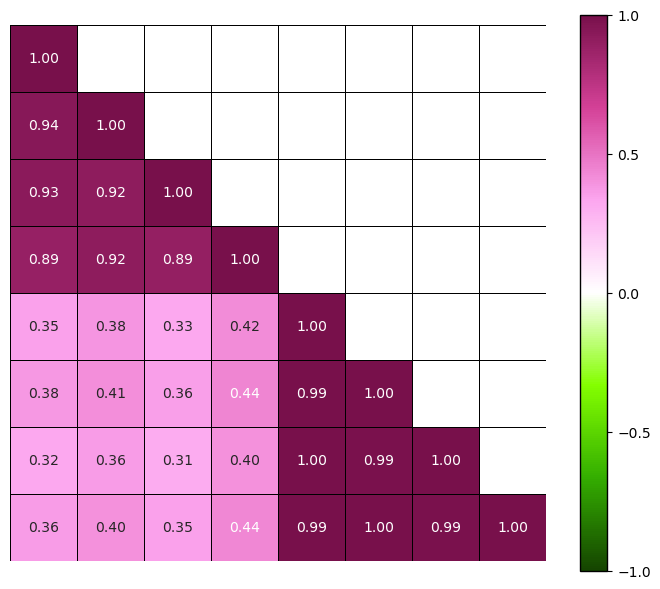

In [5]:
# Narratives: cross-task Spearman reliability heatmap (Bonferroni corrected via
# stats_helpers.multipletests re-export of statsmodels.stats.multitest.multipletests)
temp = results_df_nar.groupby(['region_name', 'task', 'measure']).mean(numeric_only=True).reset_index()
isc_piv = temp[temp['measure'] == 'ISC'].pivot_table(index='region_name', columns='task', values='score').values
ide_piv = temp[temp['measure'] == 'TPHATE_DiffOp_IDE'].pivot_table(index='region_name', columns='task', values='score').values
corrmat, pvals = spearmanr(isc_piv, ide_piv)

ind = np.triu_indices_from(pvals, k=0)
pvals_lower = pvals.copy()
pvals_lower[ind] = np.nan
corrmat_lower = corrmat.copy()
corrmat_lower[ind] = np.nan
np.fill_diagonal(corrmat_lower, 1)

reject, _, _, _ = stats_helpers.multipletests(pvals_lower[pvals_lower == pvals_lower], method='bonferroni', alpha=0.05)
reject_mat = squareform(reject)
np.fill_diagonal(reject_mat, True)  # always show the diagonal

fig, ax = plt.subplots(figsize=(7, 6))
g = sns.heatmap(corrmat_lower * reject_mat, annot=True, fmt=".2f",
                cmap=helper.diverging_colormap_gp(), linecolor='k', linewidths=0.5,
                vmin=-1, vmax=1, square=True, xticklabels=False, yticklabels=False, ax=ax)
cbar = g.collections[0].colorbar
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/narratives_cross_task_reliability_heatmap.pdf', format='pdf', transparent=True)
plt.show()

## 1.3 Average ISC, IDE, and ISC-IDE correlation by task

In [6]:
# INPUT: compiled/results/combined_corr_analyses.csv -- per-subject x task ISC-IDE permutation
#   correlation z-scores (see stats_helpers.permute_pattern for the underlying permutation test).
#   Generating step for this specific combined file is not currently in the repo
#   -- see REPRODUCIBILITY.md.
df_corr_nar = pd.read_csv('compiled/results/combined_corr_analyses.csv', index_col=0)
df_corr_nar = df_corr_nar[df_corr_nar['dataset'] == 'narratives'].reset_index()
t, p = stats.ttest_1samp(df_corr_nar['zscore'].values, 0, alternative='two-sided')
print(f"t-statistic: {t:.3f}, p-value: {p:.3e}, zscore mean: {df_corr_nar['zscore'].mean():.3f}, "
      f"degrees of freedom: {len(df_corr_nar)-1}")

t-statistic: 18.231, p-value: 8.485e-41, zscore mean: 4.546, degrees of freedom: 159


/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_26873/831540410.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set(xlabel='Task', ylabel="Pearson's r", title='Whole-brain average ISC',
/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_26873/831540410.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set(xlabel='Task', ylabel='# Dimensions', title='Whole-brain average IDE',
/var/folders/1f/s3_5gwyj4j3c18swys7lqz4w0000gn/T/ipykernel_26873/831540410.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set(xlabel='', ylabel='Z-score', title='ISC-ID relationship', ylim=(-6, 12),


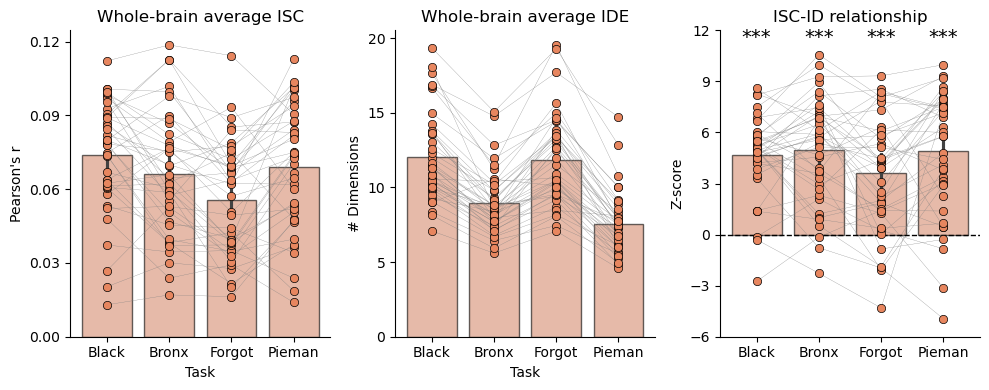

: 

In [ ]:
# Narratives: three barplots -- mean ISC, mean IDE, ISC-IDE z-score by task
tasks = ['black', 'bronx', 'forgot', 'piemanpni']
ISC_Color = helper.dataset_colors('narratives')
IDE_Color = helper.dataset_colors('narratives')
corr_color = helper.dataset_colors('narratives')

temp = results_df_nar.groupby(['task', 'measure', 'subject_id']).mean(numeric_only=True).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

# ISC barplot
g = sns.barplot(x='task', y='score', data=temp[temp['measure'] == 'ISC'],
                ax=axes[0], color=ISC_Color, edgecolor='k', linewidth=1, alpha=0.6)
sns.stripplot(x='task', y='score', data=temp[temp['measure'] == 'ISC'],
              ax=axes[0], color=ISC_Color, size=6, edgecolor='k', linewidth=0.5, jitter=False, alpha=1)
for sub in temp['subject_id'].unique():
    sub_data = temp[(temp['subject_id'] == sub) & (temp['measure'] == 'ISC')].sort_values('task')
    if len(sub_data) == 4:
        axes[0].plot(range(4), sub_data['score'].values, color='gray', alpha=1, linewidth=0.2, zorder=1)
g.set(xlabel='Task', ylabel="Pearson's r", title='Whole-brain average ISC',
      xticklabels=['Black', 'Bronx', 'Forgot', 'Pieman'], yticks=np.arange(0, 0.13, 0.03))

# IDE barplot
g = sns.barplot(x='task', y='score', data=temp[temp['measure'] == 'TPHATE_DiffOp_IDE'],
                ax=axes[1], color=IDE_Color, edgecolor='k', linewidth=1, alpha=0.6)
sns.stripplot(x='task', y='score', data=temp[temp['measure'] == 'TPHATE_DiffOp_IDE'],
              ax=axes[1], color=IDE_Color, size=6, edgecolor='k', linewidth=0.5, jitter=False, alpha=1)
for sub in temp['subject_id'].unique():
    sub_data = temp[(temp['subject_id'] == sub) & (temp['measure'] == 'TPHATE_DiffOp_IDE')].sort_values('task')
    if len(sub_data) == 4:
        axes[1].plot(range(4), sub_data['score'].values, color='gray', alpha=1, linewidth=0.2, zorder=1)
g.set(xlabel='Task', ylabel='# Dimensions', title='Whole-brain average IDE',
      xticklabels=['Black', 'Bronx', 'Forgot', 'Pieman'], yticks=np.arange(0, 22, 5))

# ISC-IDE z-score barplot
g = sns.barplot(x='task', y='zscore', data=df_corr_nar,
                ax=axes[2], color=corr_color, edgecolor='k', linewidth=1, alpha=0.6)
sns.stripplot(x='task', y='zscore', data=df_corr_nar,
              ax=axes[2], color=corr_color, size=6, edgecolor='k', linewidth=0.5, jitter=False, alpha=1)
for sub in df_corr_nar['subject'].unique():
    sub_data = df_corr_nar[df_corr_nar['subject'] == sub].sort_values('task')
    if len(sub_data) == 4:
        axes[2].plot(range(4), sub_data['zscore'].values, color='gray', alpha=1, linewidth=0.2, zorder=1)
for i, task in enumerate(tasks):
    task_data = df_corr_nar[df_corr_nar['task'] == task]
    t, p = stats.ttest_1samp(task_data['zscore'], 0, alternative='two-sided')
    axes[2].text(i, 11, helper.get_asterisks_pvalue(p), ha='center', va='bottom', fontsize=14)
axes[2].axhline(0, color='k', linestyle='--', linewidth=1)
g.set(xlabel='', ylabel='Z-score', title='ISC-ID relationship', ylim=(-6, 12),
      xticklabels=['Black', 'Bronx', 'Forgot', 'Pieman'], yticks=range(-6, 13, 3))

sns.despine()
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/narratives_avg_isc_ide_corr_barplots.pdf', format='pdf', transparent=True)
plt.show()